In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/himanshupoddar/zomato-bangalore-restaurants/zomato.csv


In [2]:
import pandas as pd

df = pd.read_csv('/kaggle/input/datasets/himanshupoddar/zomato-bangalore-restaurants/zomato.csv')
df

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51712,https://www.zomato.com/bangalore/best-brews-fo...,"Four Points by Sheraton Bengaluru, 43/3, White...",Best Brews - Four Points by Sheraton Bengaluru...,No,No,3.6 /5,27,080 40301477,Whitefield,Bar,NaN,Continental,"1,500","[('Rated 5.0', ""RATED\n Food and service are ...",[],Pubs and bars,Whitefield
51713,https://www.zomato.com/bangalore/vinod-bar-and...,"Number 10, Garudachar Palya, Mahadevapura, Whi...",Vinod Bar And Restaurant,No,No,NaN,0,+91 8197675843,Whitefield,Bar,NaN,Finger Food,600,[],[],Pubs and bars,Whitefield
51714,https://www.zomato.com/bangalore/plunge-sherat...,Sheraton Grand Bengaluru Whitefield Hotel & Co...,Plunge - Sheraton Grand Bengaluru Whitefield H...,No,No,NaN,0,NaN,Whitefield,Bar,NaN,Finger Food,"2,000",[],[],Pubs and bars,Whitefield
51715,https://www.zomato.com/bangalore/chime-sherato...,Sheraton Grand Bengaluru Whitefield Hotel & Co...,Chime - Sheraton Grand Bengaluru Whitefield Ho...,No,Yes,4.3 /5,236,080 49652769,"ITPL Main Road, Whitefield",Bar,"Cocktails, Pizza, Buttermilk",Finger Food,"2,500","[('Rated 4.0', 'RATED\n Nice and friendly pla...",[],Pubs and bars,Whitefield


In [3]:
# Checking dataset columns before starting the project
# EDA: rate, votes, cost, location
# Visualization: cuisines, restaurant type, ratings
# Sentiment Analysis: reviews_list

df.columns

Index(['url', 'address', 'name', 'online_order', 'book_table', 'rate', 'votes',
       'phone', 'location', 'rest_type', 'dish_liked', 'cuisines',
       'approx_cost(for two people)', 'reviews_list', 'menu_item',
       'listed_in(type)', 'listed_in(city)'],
      dtype='object')

In [4]:
df.shape

(51717, 17)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51717 entries, 0 to 51716
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   url                          51717 non-null  object
 1   address                      51717 non-null  object
 2   name                         51717 non-null  object
 3   online_order                 51717 non-null  object
 4   book_table                   51717 non-null  object
 5   rate                         43942 non-null  object
 6   votes                        51717 non-null  int64 
 7   phone                        50509 non-null  object
 8   location                     51696 non-null  object
 9   rest_type                    51490 non-null  object
 10  dish_liked                   23639 non-null  object
 11  cuisines                     51672 non-null  object
 12  approx_cost(for two people)  51371 non-null  object
 13  reviews_list                 51

In [6]:
df.head()

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari


In [7]:
df.isnull().sum()

url                                0
address                            0
name                               0
online_order                       0
book_table                         0
rate                            7775
votes                              0
phone                           1208
location                          21
rest_type                        227
dish_liked                     28078
cuisines                          45
approx_cost(for two people)      346
reviews_list                       0
menu_item                          0
listed_in(type)                    0
listed_in(city)                    0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.describe()

,votes
count,51717.000000
mean,283.697527
std,803.838853
min,0.000000
25%,7.000000
50%,41.000000
75%,198.000000
max,16832.000000


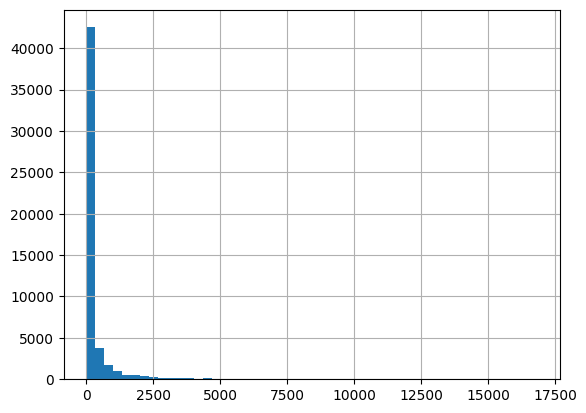

In [10]:
import matplotlib.pyplot as plt

df['votes'].hist(bins=50)
plt.show()

#Right Skewed Distribution

In [11]:
df['location'].value_counts().head(10)

location
BTM                      5124
HSR                      2523
Koramangala 5th Block    2504
JP Nagar                 2235
Whitefield               2144
Indiranagar              2083
Jayanagar                1926
Marathahalli             1846
Bannerghatta Road        1630
Bellandur                1286
Name: count, dtype: int64

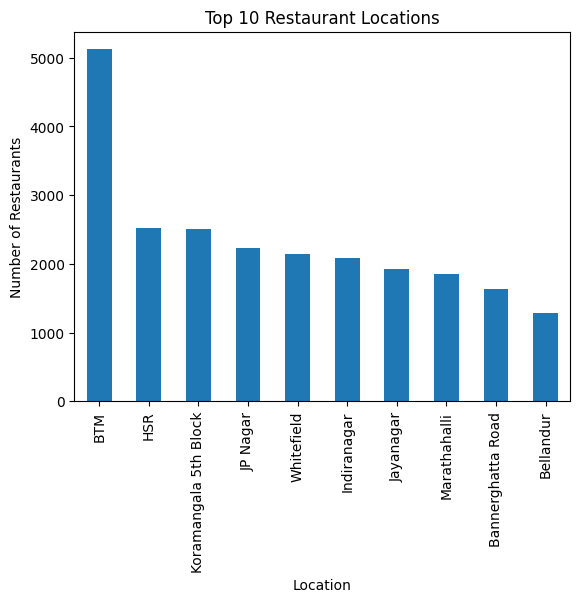

In [12]:
import matplotlib.pyplot as plt

df['location'].value_counts().head(10).plot(kind='bar')

plt.title('Top 10 Restaurant Locations')
plt.xlabel('Location')
plt.ylabel('Number of Restaurants')

plt.show()

In [13]:
df.groupby('location')['votes'].mean().sort_values(ascending=False).head(10)

location
Church Street            1045.657293
Lavelle Road              956.873346
Koramangala 5th Block     886.384185
St. Marks Road            755.963068
Koramangala 4th Block     673.703048
Cunningham Road           586.299389
Koramangala 3rd Block     579.439815
Indiranagar               574.175228
MG Road                   470.709150
Residency Road            432.524444
Name: votes, dtype: float64

In [14]:
df['rate'].head(20)

0     4.1/5
1     4.1/5
2     3.8/5
3     3.7/5
4     3.8/5
5     3.8/5
6     3.6/5
7     4.6/5
8     4.0/5
9     4.2/5
10    4.1/5
11    4.2/5
12    4.2/5
13    4.0/5
14    3.8/5
15    3.8/5
16    3.9/5
17    3.8/5
18    3.9/5
19    3.1/5
Name: rate, dtype: object

In [15]:
df['rate'].unique()

array(['4.1/5', '3.8/5', '3.7/5', '3.6/5', '4.6/5', '4.0/5', '4.2/5',
       '3.9/5', '3.1/5', '3.0/5', '3.2/5', '3.3/5', '2.8/5', '4.4/5',
       '4.3/5', 'NEW', '2.9/5', '3.5/5', nan, '2.6/5', '3.8 /5', '3.4/5',
       '4.5/5', '2.5/5', '2.7/5', '4.7/5', '2.4/5', '2.2/5', '2.3/5',
       '3.4 /5', '-', '3.6 /5', '4.8/5', '3.9 /5', '4.2 /5', '4.0 /5',
       '4.1 /5', '3.7 /5', '3.1 /5', '2.9 /5', '3.3 /5', '2.8 /5',
       '3.5 /5', '2.7 /5', '2.5 /5', '3.2 /5', '2.6 /5', '4.5 /5',
       '4.3 /5', '4.4 /5', '4.9/5', '2.1/5', '2.0/5', '1.8/5', '4.6 /5',
       '4.9 /5', '3.0 /5', '4.8 /5', '2.3 /5', '4.7 /5', '2.4 /5',
       '2.1 /5', '2.2 /5', '2.0 /5', '1.8 /5'], dtype=object)

In [16]:
df['rate'].value_counts().head(20)

rate
NEW       2208
3.9/5     2098
3.8/5     2022
3.7/5     2011
3.9 /5    1874
3.8 /5    1851
3.7 /5    1810
3.6/5     1773
4.0/5     1609
4.0 /5    1574
3.6 /5    1543
4.1/5     1474
4.1 /5    1474
3.5/5     1431
3.5 /5    1353
3.4/5     1259
3.4 /5    1217
3.3/5     1168
4.2 /5    1165
3.3 /5    1142
Name: count, dtype: int64

In [17]:
df[df['rate'] == '-'].shape[0]

69

In [18]:
import numpy as np

df['rate'] = df['rate'].replace('NEW', np.nan)
df['rate'] = df['rate'].replace('-', np.nan)

In [19]:
df['rate'].isnull().sum()

np.int64(10052)

In [20]:
df['rate'] = df['rate'].astype(str)
df['rate'] = df['rate'].str.replace('/5', '', regex=False)
df['rate'] = df['rate'].str.strip()
df['rate'] = pd.to_numeric(df['rate'], errors='coerce')

In [21]:
df['rate'].dtype

dtype('float64')

In [22]:
df['rate'].describe()

count    41665.000000
mean         3.700449
std          0.440513
min          1.800000
25%          3.400000
50%          3.700000
75%          4.000000
max          4.900000
Name: rate, dtype: float64

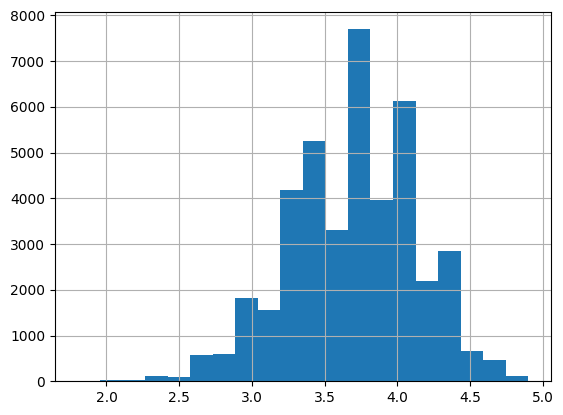

In [23]:
df['rate'].hist(bins=20)
plt.show()

In [24]:
df[['votes','rate']].corr()

,votes,rate
votes,1.00000,0.43404
rate,0.43404,1.00000


In [25]:
df.groupby('location')['rate'].mean().sort_values(ascending=False).head(10)

location
Lavelle Road             4.142505
Koramangala 3rd Block    4.020419
St. Marks Road           4.017201
Koramangala 5th Block    4.005821
Church Street            3.992125
Sankey Road              3.965385
Koramangala 4th Block    3.918668
Cunningham Road          3.901053
Residency Road           3.863636
MG Road                  3.855857
Name: rate, dtype: float64

In [26]:
#Lavelle Road and Church Street stand out as high-performing locations, showing both high customer engagement (votes) and strong restaurant ratings

In [27]:
df.groupby('online_order')['rate'].mean()

online_order
No     3.65907
Yes    3.72244
Name: rate, dtype: float64

In [28]:
df.groupby('book_table')['rate'].mean()

book_table
No     3.621470
Yes    4.143464
Name: rate, dtype: float64

In [29]:
#Restaurants that offer table booking tend to receive significantly higher ratings than restaurants that do not offer table booking

In [30]:
df.groupby('rest_type')['rate'].mean().sort_values(ascending=False).head(10)

rest_type
Pub, Cafe                      4.657500
Bar, Pub                       4.600000
Microbrewery                   4.478571
Pub, Microbrewery              4.452632
Microbrewery, Bar              4.446154
Microbrewery, Pub              4.438095
Casual Dining, Irani Cafee     4.406667
Cafe, Lounge                   4.400000
Fine Dining, Lounge            4.400000
Microbrewery, Casual Dining    4.369421
Name: rate, dtype: float64

In [31]:
df['rest_type'].value_counts().head(20)

rest_type
Quick Bites                   19132
Casual Dining                 10330
Cafe                           3732
Delivery                       2604
Dessert Parlor                 2263
Takeaway, Delivery             2037
Casual Dining, Bar             1154
Bakery                         1141
Beverage Shop                   867
Bar                             697
Food Court                      624
Sweet Shop                      468
Bar, Casual Dining              425
Lounge                          396
Pub                             357
Fine Dining                     346
Casual Dining, Cafe             319
Beverage Shop, Quick Bites      298
Bakery, Quick Bites             289
Mess                            267
Name: count, dtype: int64

In [32]:
df.groupby('rest_type')['votes'].mean().sort_values(ascending=False).head(10)

rest_type
Microbrewery                   6443.766667
Microbrewery, Pub              5504.452381
Lounge, Microbrewery           4653.000000
Pub, Cafe                      4472.875000
Pub, Microbrewery              4174.380952
Casual Dining, Irani Cafee     3686.600000
Casual Dining, Microbrewery    2527.237288
Fine Dining, Lounge            2236.785714
Microbrewery, Lounge           2225.777778
Cafe, Casual Dining            1952.329480
Name: votes, dtype: float64

In [33]:
#Microbrewery-based restaurant types consistently achieve both high customer ratings and high customer engagement, making them among the best-performing restaurant categories in the dataset. 

In [34]:
df.groupby('online_order')['votes'].mean()

online_order
No     250.31594
Yes    307.02319
Name: votes, dtype: float64

In [35]:
#Restaurants offering online ordering tend to attract greater customer engagement and receive slightly higher ratings compared to restaurants without online ordering services

In [36]:
top_locations = df['location'].value_counts().head(10)

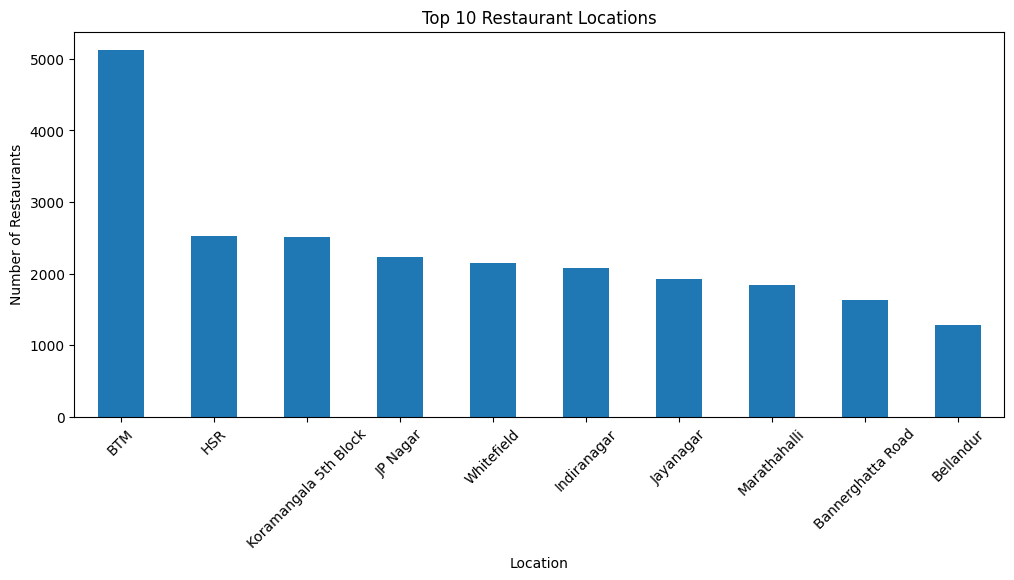

In [37]:
plt.figure(figsize=(12,5))
top_locations.plot(kind='bar')
plt.title('Top 10 Restaurant Locations')
plt.xlabel('Location')
plt.ylabel('Number of Restaurants')
plt.xticks(rotation=45)
plt.show()

In [38]:
# BTM has the highest concentration of restaurants in the dataset

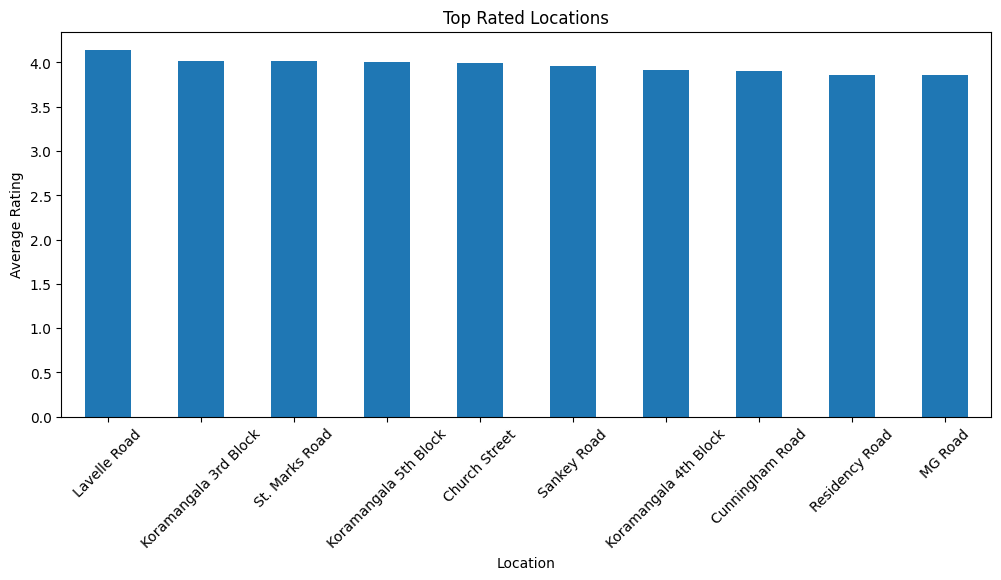

In [39]:
top_rated_locations = df.groupby('location')['rate'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,5))
top_rated_locations.plot(kind='bar')
plt.title('Top Rated Locations')
plt.xlabel('Location')
plt.ylabel('Average Rating')
plt.xticks(rotation=45)
plt.show()

In [40]:
# Lavelle Road achieved the highest average restaurant rating

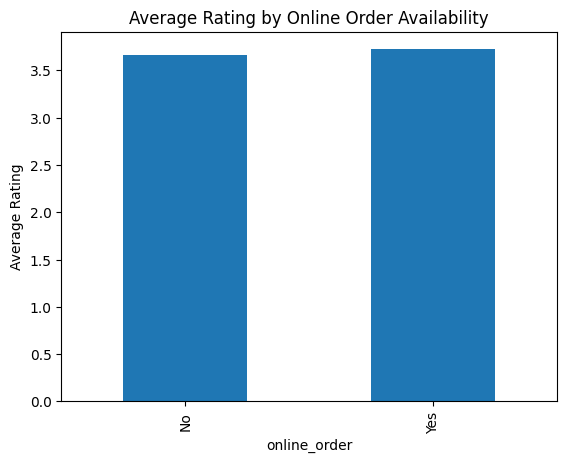

In [41]:
df.groupby('online_order')['rate'].mean().plot(kind='bar')

plt.title('Average Rating by Online Order Availability')
plt.ylabel('Average Rating')
plt.show()

In [42]:
# Restaurants offering online ordering tend to receive slightly higher ratings

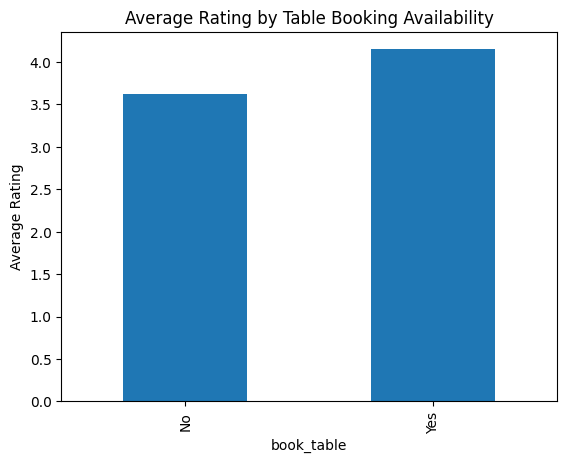

In [43]:
df.groupby('book_table')['rate'].mean().plot(kind='bar')

plt.title('Average Rating by Table Booking Availability')
plt.ylabel('Average Rating')
plt.show()

In [44]:
# Restaurants offering table booking receive significantly higher ratings

1. The average restaurant rating is 3.7.
2. Lavelle Road achieved the highest average rating.
3. Customer votes and ratings show a moderate positive correlation (0.434).
4. Restaurants offering online ordering receive slightly higher ratings.
5. Restaurants offering table booking receive significantly higher ratings.
6. Microbrewery restaurant types achieved both high ratings and high customer engagement.

In [45]:
#Task3

In [46]:
df['reviews_list'].sample(5)

4836     [('Rated 4.0', "RATED\n  This place is exactly...
9904     [('Rated 1.0', "RATED\n  Ok so I saw there is ...
30438    [('Rated 5.0', 'RATED\n  Lovely ice cream and ...
30592    [('Rated 5.0', 'RATED\n  Great food with super...
13979    [('Rated 5.0', 'RATED\n  Can say best cafe in ...
Name: reviews_list, dtype: object

In [47]:
df['reviews_list'].isnull().sum()

np.int64(0)

In [48]:
df['reviews_list'].iloc[0]

'[(\'Rated 4.0\', \'RATED\\n  A beautiful place to dine in.The interiors take you back to the Mughal era. The lightings are just perfect.We went there on the occasion of Christmas and so they had only limited items available. But the taste and service was not compromised at all.The only complaint is that the breads could have been better.Would surely like to come here again.\'), (\'Rated 4.0\', \'RATED\\n  I was here for dinner with my family on a weekday. The restaurant was completely empty. Ambience is good with some good old hindi music. Seating arrangement are good too. We ordered masala papad, panner and baby corn starters, lemon and corrionder soup, butter roti, olive and chilli paratha. Food was fresh and good, service is good too. Good for family hangout.\\nCheers\'), (\'Rated 2.0\', \'RATED\\n  Its a restaurant near to Banashankari BDA. Me along with few of my office friends visited to have buffet but unfortunately they only provide veg buffet. On inquiring they said this plac

In [49]:
!pip install vaderSentiment

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 4.2 MB/s eta 0:00:00


In [50]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

sample_review = str(df['reviews_list'].iloc[0])

analyzer.polarity_scores(sample_review)

{'neg': 0.031, 'neu': 0.717, 'pos': 0.252, 'compound': 0.9996}

In [51]:
def get_sentiment(text):
    score = analyzer.polarity_scores(str(text))['compound']

    if score >= 0.05:
        return 'Positive'
    elif score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

In [52]:
sample_df = df.sample(100, random_state=42)

sample_df['sentiment'] = sample_df['reviews_list'].apply(get_sentiment)

sample_df['sentiment'].value_counts()

sentiment
Positive    72
Neutral     21
Negative     7
Name: count, dtype: int64

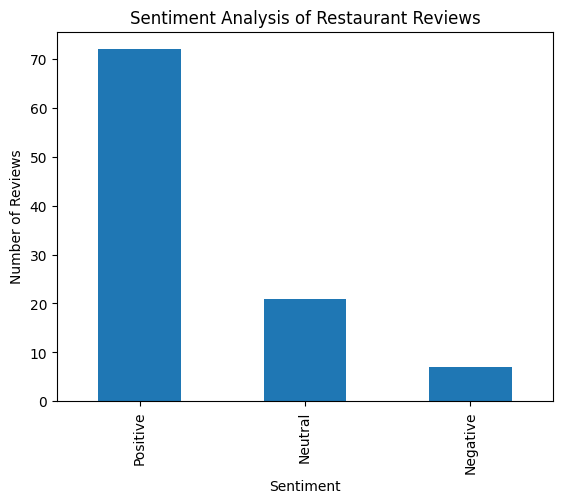

In [53]:
sample_df['sentiment'].value_counts().plot(kind='bar')

plt.title('Sentiment Analysis of Restaurant Reviews')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.show()

## Sentiment Analysis Results

- Positive Reviews: 72%
- Neutral Reviews: 21%
- Negative Reviews: 7%

Most customer reviews are positive, indicating overall customer satisfaction.